In [1]:
try: 
    import kagglehub #pip install kagglehub
    kagglehub.login()
    path = kagglehub.competition_download('aca-butterflies')
    print("Path to dataset files:", path)
    
except ImportError as e:
    from pathlib import Path
    path = Path().cwd()  / "aca-butterflies"

In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import torch.nn as nn
import torch.utils.data as data
import torchvision.transforms as transforms
import torch.nn.functional as F
from torchvision.transforms import v2
import numpy as np
import copy
import time

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = 64


In [4]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

# First, we read the dataset, preprocess the images and encapsulate them into dataloader form

In [5]:
# load the data
img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

### Train/Test 70/30: Stratified

In [6]:
targets = dataset.img_labels['label'].values 

# Stratified: 70 / 30
train_indices, val_indices = train_test_split(
    range(len(dataset)),
    test_size=0.3,
    stratify=targets,
    random_state=42
)

# DATA AUGMENTATION FOR TRAINING SET
train_transform = v2.Compose([      # ⚠️ ver se aplica de maneira igual a todos as classes
    v2.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(15),
    v2.ToTensor(),
    # v2.Normalize((0.5,), (0.5,))
])

# Subsets
train_dataset = Subset(dataset, train_indices)
train_dataset.dataset = copy.copy(dataset)
train_dataset.dataset.transform = train_transform  # Apply augmentation only to training set
val_dataset = Subset(dataset, val_indices)

# DataLoaders
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Imagens para treino: {len(train_dataset)}")
print(f"Imagens para validação: {len(val_dataset)}")

Imagens para treino: 3639
Imagens para validação: 1560


C:\Users\João Cascais\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [7]:
# VERIFY SAMPLES AND CLASSES
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


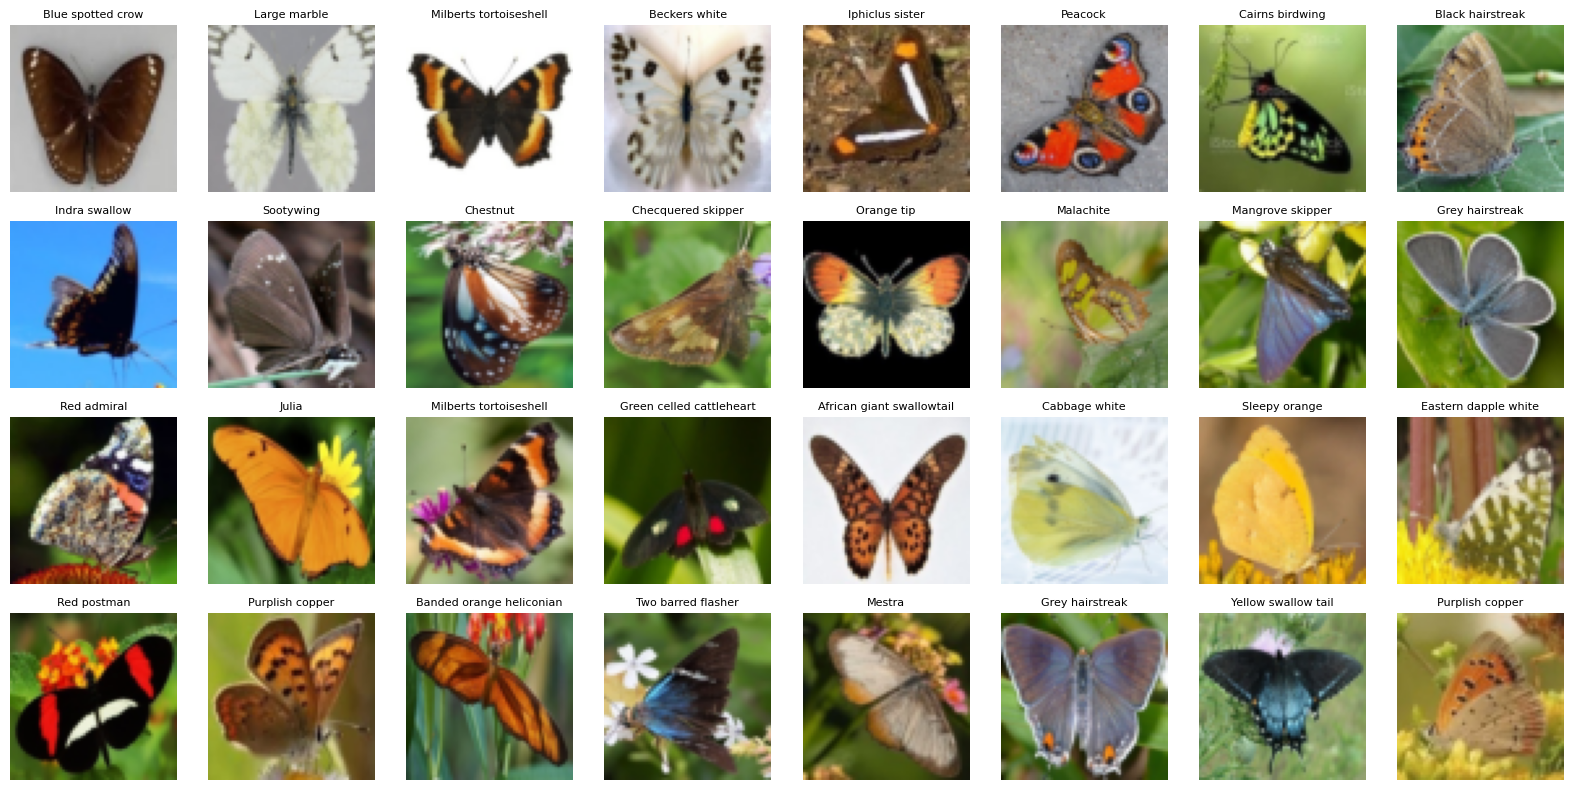

In [8]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(len(images)):
    img = images[i].permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]

    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### ResNET First Implementation

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride = 1, downsample = None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Sequential(
                        nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1),
                        nn.BatchNorm2d(out_channels),
                        nn.ReLU())
        self.conv2 = nn.Sequential(
                        nn.Conv2d(out_channels, out_channels, kernel_size = 3, stride = 1, padding = 1),
                        nn.BatchNorm2d(out_channels))
        self.downsample = downsample
        self.relu = nn.ReLU()
        self.out_channels = out_channels

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.conv2(out)
        if self.downsample:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out

In [12]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes = 10):
        super(ResNet, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Sequential(
                        nn.Conv2d(3, 64, kernel_size = 7, stride = 2, padding = 3),
                        nn.BatchNorm2d(64),
                        nn.ReLU())
        self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)
        self.layer0 = self._make_layer(block, 64, layers[0], stride = 1)
        self.layer1 = self._make_layer(block, 128, layers[1], stride = 2)
        self.layer2 = self._make_layer(block, 256, layers[2], stride = 2)
        self.layer3 = self._make_layer(block, 512, layers[3], stride = 2)
        self.avgpool = nn.AvgPool2d(7, stride=1)
        # self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes:

            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride),
                nn.BatchNorm2d(planes),
            )
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

In [13]:
import gc

num_classes = 75
num_epochs = 50
learning_rate = 0.01

# Initialize model with 75 classes
model = ResNet(ResidualBlock, [3, 4, 6, 3], num_classes=num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=0.001, momentum=0.9)  

total_step = len(train_loader)

# Train the model
for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    for i, (images, labels) in enumerate(train_loader):  
        # Move tensors to the configured device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Clean up batch variables to save memory
        del images, labels, outputs

    # Print loss at the end of the epoch
    print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))

    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (important for BatchNorm/Dropout)
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            del images, labels, outputs

        print('Accuracy of the network on validation images: {} %'.format(100 * correct / total))
        
    # Optional: Clear cache at the end of an epoch (much safer than every batch)
    torch.cuda.empty_cache()
    gc.collect()

# --- TESTING PHASE (Runs exactly once after all 20 epochs) ---
# print("\n--- Training Complete. Starting Testing ---")
# model.eval()
# with torch.no_grad():
#     correct = 0
#     total = 0
#     for images, labels in test_loader:
#         images = images.to(device)
#         labels = labels.to(device)
        
#         outputs = model(images)
#         _, predicted = torch.max(outputs.data, 1)
        
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()
#         del images, labels, outputs

#     print('Accuracy of the network on test images: {} %'.format(100 * correct / total))

Epoch [1/50], Loss: 3.2200
Accuracy of the network on validation images: 8.333333333333334 %
Epoch [2/50], Loss: 2.8859
Accuracy of the network on validation images: 15.576923076923077 %
Epoch [3/50], Loss: 3.3468
Accuracy of the network on validation images: 20.384615384615383 %
Epoch [4/50], Loss: 2.9419
Accuracy of the network on validation images: 29.294871794871796 %
Epoch [5/50], Loss: 3.5080
Accuracy of the network on validation images: 25.512820512820515 %
Epoch [6/50], Loss: 2.2990
Accuracy of the network on validation images: 28.141025641025642 %
Epoch [7/50], Loss: 2.1124
Accuracy of the network on validation images: 39.294871794871796 %
Epoch [8/50], Loss: 2.0261
Accuracy of the network on validation images: 46.794871794871796 %
Epoch [9/50], Loss: 1.7445
Accuracy of the network on validation images: 42.11538461538461 %
Epoch [10/50], Loss: 1.3701
Accuracy of the network on validation images: 51.47435897435897 %
Epoch [11/50], Loss: 1.3035
Accuracy of the network on validat

### Second Implementation

In [10]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, pool_type='max'):
        super(ResidualBlock, self).__init__()
        padding = kernel_size // 2
        
        # F(x) - O caminho das convoluções
        self.conv_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(out_channels)
        )
        
        # O Atalho (Skip Connection)
        # Se o stride > 1 ou canais mudarem, precisamos ajustar x para a soma ser possível
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
            
        self.pool = nn.MaxPool2d(2,2) if pool_type == "max" else nn.AvgPool2d(2,2)
        self.relu = nn.ReLU()

    def forward(self, x):
        # H(x) = F(x) + x
        residual = self.shortcut(x)
        out = self.conv_path(x)
        out += residual # Soma do resíduo
        out = self.relu(out)
        return self.pool(out)

In [11]:
class SuperResNet(nn.Module):
    def __init__(self, config, num_classes=75):
        super(SuperResNet, self).__init__()
        
        k = config["kernel_size"]
        s = config["stride"]
        pool = config["pool"]
        dropout = config["dropout"]
        c1, c2, c3, c4 = config["channels"]

        # Bloco 1: Entrada 3 -> c1
        self.block1 = ResidualBlock(3, c1, k, stride=s, pool_type=pool)
        
        # Bloco 2: c1 -> c2
        self.block2 = ResidualBlock(c1, c2, k, stride=s, pool_type=pool)
        
        # Bloco 3: c2 -> c3
        self.block3 = ResidualBlock(c2, c3, k, stride=1, pool_type=pool)
        
        # Bloco 4: c3 -> c4
        self.block4 = nn.Sequential(
            nn.Conv2d(c3, c4, k, padding=k//2),
            nn.BatchNorm2d(c4),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(c4, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.fc(x)
        return x
    
# TRAIN + EVAL
def evaluate(model, dataloader, criterion):
    model.eval()
    correct = 0
    total = 0
    loss_total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    loss_avg = loss_total / len(dataloader)
    return acc, loss_avg


# FIT FUNCTION (EARLY STOP + PRUNING)
def fit(model, train_loader, val_loader, optimizer, criterion, trial,
        epochs=20, patience=5, folder="Results/CNN/", filename=None, plot=True):

    train_acc_graph, val_acc_graph = [], []
    train_loss_graph, val_loss_graph = [], []
    time_values = []

    best_val_loss = float("inf")
    best_val_acc = 0
    p = 0

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_acc, _ = evaluate(model, train_loader, criterion)
        val_acc, val_loss = evaluate(model, val_loader, criterion)
        train_loss = total_loss / len(train_loader)

        # PRUNING (Optuna)
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            p = 0
        else:
            p += 1

        if p >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        # STORE
        train_acc_graph.append(train_acc * 100)
        val_acc_graph.append(val_acc * 100)
        train_loss_graph.append(train_loss)
        val_loss_graph.append(val_loss)
        time_values.append(time.time() - start_time)

        print(f"[{epoch+1}] Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

    # PLOTS
    plt.figure()
    plt.plot(train_acc_graph, label="Train Acc")
    plt.plot(val_acc_graph, label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.savefig(folder + f"acc_{filename}.png")
    plt.close()

    plt.figure()
    plt.plot(train_loss_graph, label="Train Loss")
    plt.plot(val_loss_graph, label="Val Loss")
    plt.legend()
    plt.title("Loss")
    plt.savefig(folder + f"loss_{filename}.png")
    plt.close()

    df = pd.DataFrame({"train_acc": train_acc_graph, "val_acc": val_acc_graph, "train_loss": train_loss_graph, "val_loss": val_loss_graph, "time": time_values})
    if filename is not None:
        df.to_csv(folder + filename + ".csv", index=True, index_label="epoch")

    
    return best_val_acc, epoch + 1

In [12]:
import optuna

def objective(trial):
    # Dicionários de Loss e Opt (os mesmos que já tens)
    losses = {'CrossEntropy': nn.CrossEntropyLoss, 'MultiMargin': nn.MultiMarginLoss}
    optimizers_dict = {'ADAM': torch.optim.Adam, 'RMS': torch.optim.RMSprop}

    config = {
        "kernel_size": trial.suggest_categorical("kernel_size", [3, 5]),
        "stride": trial.suggest_categorical("stride", [1, 2]),
        "pool": trial.suggest_categorical("pool", ["max", "avg"]),
        "dropout": trial.suggest_float("dropout", 0.2, 0.6),
        "channels": [
            trial.suggest_categorical("c1", [32, 64]),
            trial.suggest_categorical("c2", [64, 128]),
            trial.suggest_categorical("c3", [128, 256]),
            trial.suggest_categorical("c4", [256, 512])
        ],
        "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    }

    # INSTANCIAR A RESNET
    model = SuperResNet(config).to(device)

    loss_name = trial.suggest_categorical('loss_fn', list(losses.keys()))
    criterion = losses[loss_name]()
    
    opt_name = trial.suggest_categorical('optimizer', list(optimizers_dict.keys()))
    optimizer = optimizers_dict[opt_name](model.parameters(), lr=config["lr"])

    # RODAR O FIT (A tua função fit atualizada que retorna acc e epochs)
    acc, epochs_used = fit(
        model, train_loader, val_loader, optimizer, criterion, trial,
        epochs=50, patience=10, folder="Results/ResNet/", 
        filename=f"resnet_trial_{trial.number}", plot=False
    )

    trial.set_user_attr("epochs_used", epochs_used)
    return acc

# Criar e rodar o estudo
study_resnet = optuna.create_study(
    study_name="ResNet_Optimization",
    direction="maximize",
    storage="sqlite:///resnet_study.db",
    load_if_exists=True
)

study_resnet.optimize(objective, n_trials=20)

C:\Users\João Cascais\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-10 20:18:24,731] A new study created in RDB with name: ResNet_Optimization


[1] Train Acc: 0.086 | Val Acc: 0.094
[2] Train Acc: 0.123 | Val Acc: 0.119
[3] Train Acc: 0.165 | Val Acc: 0.157
[4] Train Acc: 0.206 | Val Acc: 0.190
[5] Train Acc: 0.203 | Val Acc: 0.190
[6] Train Acc: 0.307 | Val Acc: 0.289
[7] Train Acc: 0.329 | Val Acc: 0.302
[8] Train Acc: 0.356 | Val Acc: 0.304
[9] Train Acc: 0.397 | Val Acc: 0.353
[10] Train Acc: 0.443 | Val Acc: 0.383
[11] Train Acc: 0.418 | Val Acc: 0.355
[12] Train Acc: 0.447 | Val Acc: 0.394
[13] Train Acc: 0.498 | Val Acc: 0.446
[14] Train Acc: 0.482 | Val Acc: 0.428
[15] Train Acc: 0.508 | Val Acc: 0.453
[16] Train Acc: 0.566 | Val Acc: 0.502
[17] Train Acc: 0.483 | Val Acc: 0.435
[18] Train Acc: 0.533 | Val Acc: 0.442
[19] Train Acc: 0.529 | Val Acc: 0.458
[20] Train Acc: 0.627 | Val Acc: 0.528
[21] Train Acc: 0.591 | Val Acc: 0.490
[22] Train Acc: 0.632 | Val Acc: 0.519
[23] Train Acc: 0.624 | Val Acc: 0.529
[24] Train Acc: 0.653 | Val Acc: 0.541
[25] Train Acc: 0.707 | Val Acc: 0.566
[26] Train Acc: 0.714 | Val Acc: 0

[I 2026-04-10 20:26:44,414] Trial 0 finished with value: 0.6538461538461539 and parameters: {'kernel_size': 5, 'stride': 2, 'pool': 'avg', 'dropout': 0.5974416278626336, 'c1': 64, 'c2': 128, 'c3': 128, 'c4': 256, 'lr': 0.0002886325503169542, 'loss_fn': 'CrossEntropy', 'optimizer': 'RMS'}. Best is trial 0 with value: 0.6538461538461539.


Early stopping at epoch 47
[1] Train Acc: 0.055 | Val Acc: 0.053
[2] Train Acc: 0.050 | Val Acc: 0.051
[3] Train Acc: 0.040 | Val Acc: 0.044
[4] Train Acc: 0.055 | Val Acc: 0.053
[5] Train Acc: 0.055 | Val Acc: 0.050
[6] Train Acc: 0.047 | Val Acc: 0.038
[7] Train Acc: 0.053 | Val Acc: 0.047
[8] Train Acc: 0.049 | Val Acc: 0.050
[9] Train Acc: 0.059 | Val Acc: 0.061
[10] Train Acc: 0.049 | Val Acc: 0.045
[11] Train Acc: 0.050 | Val Acc: 0.050
[12] Train Acc: 0.038 | Val Acc: 0.045
[13] Train Acc: 0.053 | Val Acc: 0.052
[14] Train Acc: 0.037 | Val Acc: 0.038


[I 2026-04-10 20:29:16,591] Trial 1 finished with value: 0.05 and parameters: {'kernel_size': 5, 'stride': 2, 'pool': 'avg', 'dropout': 0.20484767114149577, 'c1': 32, 'c2': 64, 'c3': 128, 'c4': 512, 'lr': 0.002228847054512119, 'loss_fn': 'MultiMargin', 'optimizer': 'ADAM'}. Best is trial 0 with value: 0.6538461538461539.


...

[I 2026-04-10 21:38:36,372] Trial 15 pruned. 


[1] Train Acc: 0.138 | Val Acc: 0.131
[2] Train Acc: 0.169 | Val Acc: 0.172


[I 2026-04-10 21:39:19,689] Trial 16 pruned. 
[I 2026-04-10 21:39:38,413] Trial 17 pruned. 
[I 2026-04-10 21:39:50,922] Trial 18 pruned. 


[1] Train Acc: 0.113 | Val Acc: 0.108
[2] Train Acc: 0.182 | Val Acc: 0.162
[3] Train Acc: 0.285 | Val Acc: 0.278
[4] Train Acc: 0.357 | Val Acc: 0.336
[5] Train Acc: 0.406 | Val Acc: 0.386


[I 2026-04-10 21:41:42,723] Trial 19 pruned. 


### Third Implementation

In [19]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, pool_type='max'):
        super(ResidualBlock, self).__init__()
        padding = kernel_size // 2
        
        # F(x) - O caminho das convoluções
        self.conv_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(out_channels)
        )
        
        # O Atalho (Skip Connection)
        # Se o stride > 1 ou canais mudarem, precisamos ajustar x para a soma ser possível
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
            
        if pool_type == "max":
            self.pool = nn.MaxPool2d(2)
        elif pool_type == "avg":
            self.pool = nn.AvgPool2d(2)
        else:
            self.pool = nn.Identity()  # 🔥 importante
        self.relu = nn.ReLU()

    def forward(self, x):
        # H(x) = F(x) + x
        residual = self.shortcut(x)
        out = self.conv_path(x)
        out += residual # Soma do resíduo
        out = self.relu(out)
        return self.pool(out)

In [20]:
class ResNet2(nn.Module):
    def __init__(self, config, num_classes=75):
        super(ResNet2, self).__init__()
        
        k = config["kernel_size"]
        s = config["stride"]
        pool = config["pool"]
        dropout = config["dropout"]
        c1, c2, c3, c4, c5, c6 = config["channels"]  # now 6 channels!

        # Bloco 1: Entrada 3 -> c1
        self.block1 = ResidualBlock(3, c1, k, stride=s, pool_type=None)
        
        # Bloco 2: c1 -> c2
        self.block2 = ResidualBlock(c1, c2, k, stride=s, pool_type=None)
        
        # Bloco 3: c2 -> c3
        self.block3 = ResidualBlock(c2, c3, k, stride=1, pool_type=None)
        
        # Bloco 4: c3 -> c4
        self.block4 = ResidualBlock(c3, c4, k, stride=1, pool_type=None)

        # Bloco 5: c4 -> c5
        self.block5 = ResidualBlock(c4, c5, k, stride=1, pool_type=None)

        # Bloco 6: c5 -> c6 + global pooling
        self.block6 = nn.Sequential(
            nn.Conv2d(c5, c6, k, padding=k//2),
            nn.BatchNorm2d(c6),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(c6, 256),  # updated input
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)  # NEW
        x = self.block6(x)  # NEW
        x = self.fc(x)
        return x

    
# TRAIN + EVAL
def evaluate(model, dataloader, criterion):
    model.eval()
    correct = 0
    total = 0
    loss_total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    loss_avg = loss_total / len(dataloader)
    return acc, loss_avg


# FIT FUNCTION (EARLY STOP + PRUNING)
def fit(model, train_loader, val_loader, optimizer, criterion, trial,
        epochs=20, patience=5, folder="Results/CNN/", filename=None, plot=True):

    train_acc_graph, val_acc_graph = [], []
    train_loss_graph, val_loss_graph = [], []
    time_values = []

    best_val_loss = float("inf")
    best_val_acc = 0
    p = 0

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_acc, _ = evaluate(model, train_loader, criterion)
        val_acc, val_loss = evaluate(model, val_loader, criterion)
        train_loss = total_loss / len(train_loader)

        # PRUNING (Optuna)
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            p = 0
        else:
            p += 1

        if p >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        # STORE
        train_acc_graph.append(train_acc * 100)
        val_acc_graph.append(val_acc * 100)
        train_loss_graph.append(train_loss)
        val_loss_graph.append(val_loss)
        time_values.append(time.time() - start_time)

        print(f"[{epoch+1}] Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

    # PLOTS
    plt.figure()
    plt.plot(train_acc_graph, label="Train Acc")
    plt.plot(val_acc_graph, label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.savefig(folder + f"acc_{filename}.png")
    plt.close()

    plt.figure()
    plt.plot(train_loss_graph, label="Train Loss")
    plt.plot(val_loss_graph, label="Val Loss")
    plt.legend()
    plt.title("Loss")
    plt.savefig(folder + f"loss_{filename}.png")
    plt.close()

    df = pd.DataFrame({"train_acc": train_acc_graph, "val_acc": val_acc_graph, "train_loss": train_loss_graph, "val_loss": val_loss_graph, "time": time_values})
    if filename is not None:
        df.to_csv(folder + filename + ".csv", index=True, index_label="epoch")

    
    return best_val_acc, epoch + 1

In [21]:
import optuna

def objective(trial):
    # Dicionários de Loss e Opt (os mesmos que já tens)
    losses = {'CrossEntropy': nn.CrossEntropyLoss, 'MultiMargin': nn.MultiMarginLoss}
    optimizers_dict = {'ADAM': torch.optim.Adam, 'RMS': torch.optim.RMSprop}

    config = {
        "kernel_size": trial.suggest_categorical("kernel_size", [3, 5]),
        "stride": trial.suggest_categorical("stride", [1, 2]),
        "pool": trial.suggest_categorical("pool", ["max", "avg"]),
        "dropout": trial.suggest_float("dropout", 0.2, 0.6),
        "channels": [
            trial.suggest_categorical("c1", [32, 64]),
            trial.suggest_categorical("c2", [64, 128]),
            trial.suggest_categorical("c3", [128, 256]),
            trial.suggest_categorical("c4", [256, 512]),
            trial.suggest_categorical("c5", [256, 512]),
            trial.suggest_categorical("c6", [512, 1024])
        ],
        "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    }

    # INSTANCIAR A RESNET
    model = ResNet2(config).to(device)

    loss_name = trial.suggest_categorical('loss_fn', list(losses.keys()))
    criterion = losses[loss_name]()
    
    opt_name = trial.suggest_categorical('optimizer', list(optimizers_dict.keys()))
    optimizer = optimizers_dict[opt_name](model.parameters(), lr=config["lr"])

    # RODAR O FIT (A tua função fit atualizada que retorna acc e epochs)
    acc, epochs_used = fit(
        model, train_loader, val_loader, optimizer, criterion, trial,
        epochs=50, patience=10, folder="Results/ResNet/optuna2/", 
        filename=f"resnet_trial_{trial.number}", plot=False
    )

    trial.set_user_attr("epochs_used", epochs_used)
    return acc

# Criar e rodar o estudo
study_resnet = optuna.create_study(
    study_name="ResNet_Optimization_2",
    direction="maximize",
    storage="sqlite:///resnet_study_2.db",
    load_if_exists=True
)

study_resnet.optimize(objective, n_trials=20)

[I 2026-04-10 22:47:57,750] Using an existing study with name 'ResNet_Optimization_2' instead of creating a new one.


[1] Train Acc: 0.015 | Val Acc: 0.013
[2] Train Acc: 0.058 | Val Acc: 0.054


[W 2026-04-10 23:02:54,638] Trial 2 failed with parameters: {'kernel_size': 5, 'stride': 1, 'pool': 'max', 'dropout': 0.44161335365696375, 'c1': 64, 'c2': 64, 'c3': 128, 'c4': 256, 'c5': 512, 'c6': 512, 'lr': 0.001694928967817391, 'loss_fn': 'MultiMargin', 'optimizer': 'ADAM'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\João Cascais\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\João Cascais\AppData\Local\Temp\ipykernel_22848\4207929991.py", line 34, in objective
    acc, epochs_used = fit(
                       ^^^^
  File "C:\Users\João Cascais\AppData\Local\Temp\ipykernel_22848\2696527488.py", line 109, in fit
    train_acc, _ = evaluate(model, train_loader, criterion)
                   ^^^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 